In [1]:
# Imports
import sys
sys.path.insert(0, 'simulation')

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from simulation.colony import Colony, Faction, WorkerLevel, CriticalFlag, StrategicFlag, DirectiveType, Directive
from simulation.buildings import BuildingType, BuildingState, BUILDING_STATS, ResourceType

from simulation.snapshot import take_snapshot, plot_history

R = ResourceType

In [2]:
# Step 1: Create a faction and a colony
faction = Faction(faction_id=0, name="Test Faction")

colony = Colony(
    colony_id=0,
    name="Test Colony",
    system_id=0,
    population=1000.0,
    stockpile={
        int(R.MINERALS): 5000.0,
        int(R.POWER): 2000.0,
        int(R.ORGANICS): 10000.0,
        int(R.RARE_MATS): 100.0,
    },
)

faction.add_colony(colony)

print(f"Created faction: {faction.name}")
print(f"Created colony: {colony.name} with population {colony.population}")

Created faction: Test Faction
Created colony: Test Colony with population 1000.0


In [3]:
# Step 2: Establish an initial set of buildings (1 of each)
building_types = [
    BuildingType.MINE,
    BuildingType.POWER_PLANT,
    BuildingType.FARM,
    BuildingType.FACTORY,
    BuildingType.FORT,
    BuildingType.SHIPYARD,
    BuildingType.RAILYARD,
    BuildingType.LAB,
]

for bt in building_types:
    colony.construct_building(bt, planet_index=0)
    print(f"Constructed {bt.name}")

print(f"\nTotal buildings: {len(colony._buildings)}")

Constructed MINE
Constructed POWER_PLANT
Constructed FARM
Constructed FACTORY
Constructed FORT
Constructed SHIPYARD
Constructed RAILYARD
Constructed LAB

Total buildings: 8


In [4]:
# Step 3: Draft enough workers to supply those buildings
required_workers = colony.required_workers_by_level()
print(f"Required workers by level: {required_workers}")

# Recruit workers for each level
for level, count in required_workers.items():
    if level == 1:
        recruited = colony.recruit_workers(count)
    else:
        recruited = colony.recruit_workers_of_level(level, count)
    print(f"Recruited {recruited} workers at level {level}")

recruited = colony.recruit_workers(20)
print(f"Recruited {recruited} additional workers at level 1")

# Assign workers to all buildings
for b in colony._buildings:
    colony.assign_workers_to_building(b)

print(f"\nTotal workers: {len(colony._workers)}")
print(f"Workers by level: {colony.workers_by_level()}")

Required workers by level: {}
Recruited 20 additional workers at level 1

Total workers: 20
Workers by level: {1: 20}


In [5]:
# Function to get net production rates (production - consumption)
def get_net_rates(colony):
    """Get net production rates for all resources."""
    from simulation.buildings import colony_production_rates, colony_production_costs
    
    produced = colony_production_rates(colony.building_counts)
    consumed = colony_production_costs(colony.building_counts)
    
    # Add population upkeep
    if R.ORGANICS not in consumed:
        consumed[R.ORGANICS] = colony.organics_upkeep_per_tick
    else:
        consumed[R.ORGANICS] += colony.organics_upkeep_per_tick
    
    all_keys = set(produced) | set(consumed)
    return {k: produced.get(k, 0.0) - consumed.get(k, 0.0) for k in all_keys}

# Function to get demand for each resource
def get_demand(colony):
    """Get consumption/demand for each resource."""
    from simulation.buildings import colony_production_costs
    
    consumed = colony_production_costs(colony.building_counts)
    
    # Add population upkeep
    consumed[R.ORGANICS] = consumed.get(R.ORGANICS, 0.0) + colony.organics_upkeep_per_tick
    
    return consumed

In [6]:
# Step 4-6: Dynamic directive system
# Start with ORGANICS focus, then progressively address lowest rates

def get_resource_priority_order(net_rates):
    """Sort resources by net rate (lowest first), excluding synthetic resources."""
    real_resources = [R.MINERALS, R.POWER, R.ORGANICS, R.RARE_MATS]
    return sorted(real_resources, key=lambda r: net_rates.get(int(r), 0.0))

def issue_directive_for_resource(colony, resource_type):
    """Issue a HARVEST directive focused on a specific resource."""
    faction.issue_directive(
        colony_id=colony.colony_id,
        directive_type=DirectiveType.HARVEST,
        tax_rate=0.10,
        urgency=1.0,
        target_resource=int(resource_type),
    )

# Step 4: Issue initial directive to focus on ORGANICS
print("Initial directive: Focusing on ORGANICS")
issue_directive_for_resource(colony, R.ORGANICS)

# Track history for plotting
history = []

# Track which resources have been addressed
addressed_resources = set()
current_focus = R.ORGANICS

Initial directive: Focusing on ORGANICS


In [ ]:
# Run simulation
NUM_TICKS = 300

for tick in range(1, NUM_TICKS + 1):
    # Run one tick
    faction.tick()
    
    # Get current net rates
    net_rates = get_net_rates(colony)
    demand = get_demand(colony)
    
    # Check if current focus resource is at 120% of demand
    focus_key = int(current_focus)
    current_rate = net_rates.get(focus_key, 0.0)
    current_demand = demand.get(focus_key, 0.1)  # Avoid division by zero
    
    if current_rate >= 1.2 * current_demand:
        # Current focus is doing well, check next lowest rate
        priority_order = get_resource_priority_order(net_rates)
        
        # Find the next resource that isn't already addressed
        for res in priority_order:
            if res not in addressed_resources and res != current_focus:
                # Check if this resource needs attention (negative or low rate)
                res_key = int(res)
                res_rate = net_rates.get(res_key, 0.0)
                res_demand = demand.get(res_key, 0.1)
                
                # Only switch if the current resource is well above 120%
                # and the new resource is below 120%
                if res_rate < 1.2 * res_demand:
                    # Issue directive for this resource
                    print(f"Tick {tick}: Switching focus from {current_focus.name} to {res.name}")
                    print(f"  {current_focus.name}: rate={current_rate:.2f}, demand={current_demand:.2f} ({current_rate/current_demand*100:.1f}%)")
                    print(f"  {res.name}: rate={res_rate:.2f}, demand={res_demand:.2f} ({res_rate/res_demand*100:.1f}%)")
                    
                    issue_directive_for_resource(colony, res)
                    addressed_resources.add(current_focus)
                    current_focus = res
                    break
    
    # Record history
    # if tick % 1 == 0 or tick <= 10:  # Record more frequently at start
    history.append(take_snapshot(faction.colonies[0]))

print(f"\nSimulation complete: {NUM_TICKS} ticks")
print(f"Final population: {colony.population:.1f}")
print(f"Final workers: {len(colony._workers)}")

======   Tick 1   ======
======   Tick 2   ======
======   Tick 3   ======
======   Tick 4   ======
======   Tick 5   ======
======   Tick 6   ======
======   Tick 7   ======
======   Tick 8   ======
Colony Test Colony (id=0):  FARM lv1 (id=2) construction complete.
Colony Test Colony (id=0):  Assigned 5 worker(s) to FARM lv1 (id=2).
======   Tick 9   ======
======   Tick 10   ======
Colony Test Colony (id=0):  MINE lv1 (id=0) construction complete.
Colony Test Colony (id=0):  Assigned 4 worker(s) to MINE lv1 (id=0).
======   Tick 11   ======
======   Tick 12   ======
Colony Test Colony (id=0):  POWER_PLANT lv1 (id=1) construction complete.
Colony Test Colony (id=0):  Assigned 2 worker(s) to POWER_PLANT lv1 (id=1).
======   Tick 13   ======
======   Tick 14   ======
======   Tick 15   ======
Colony Test Colony (id=0):  FACTORY lv1 (id=3) construction complete.
Colony Test Colony (id=0):  ⚠ FACTORY lv1 (id=3) INACTIVE — worker shortage.
Colony Test Colony (id=0):  LAB lv1 (id=7) constru

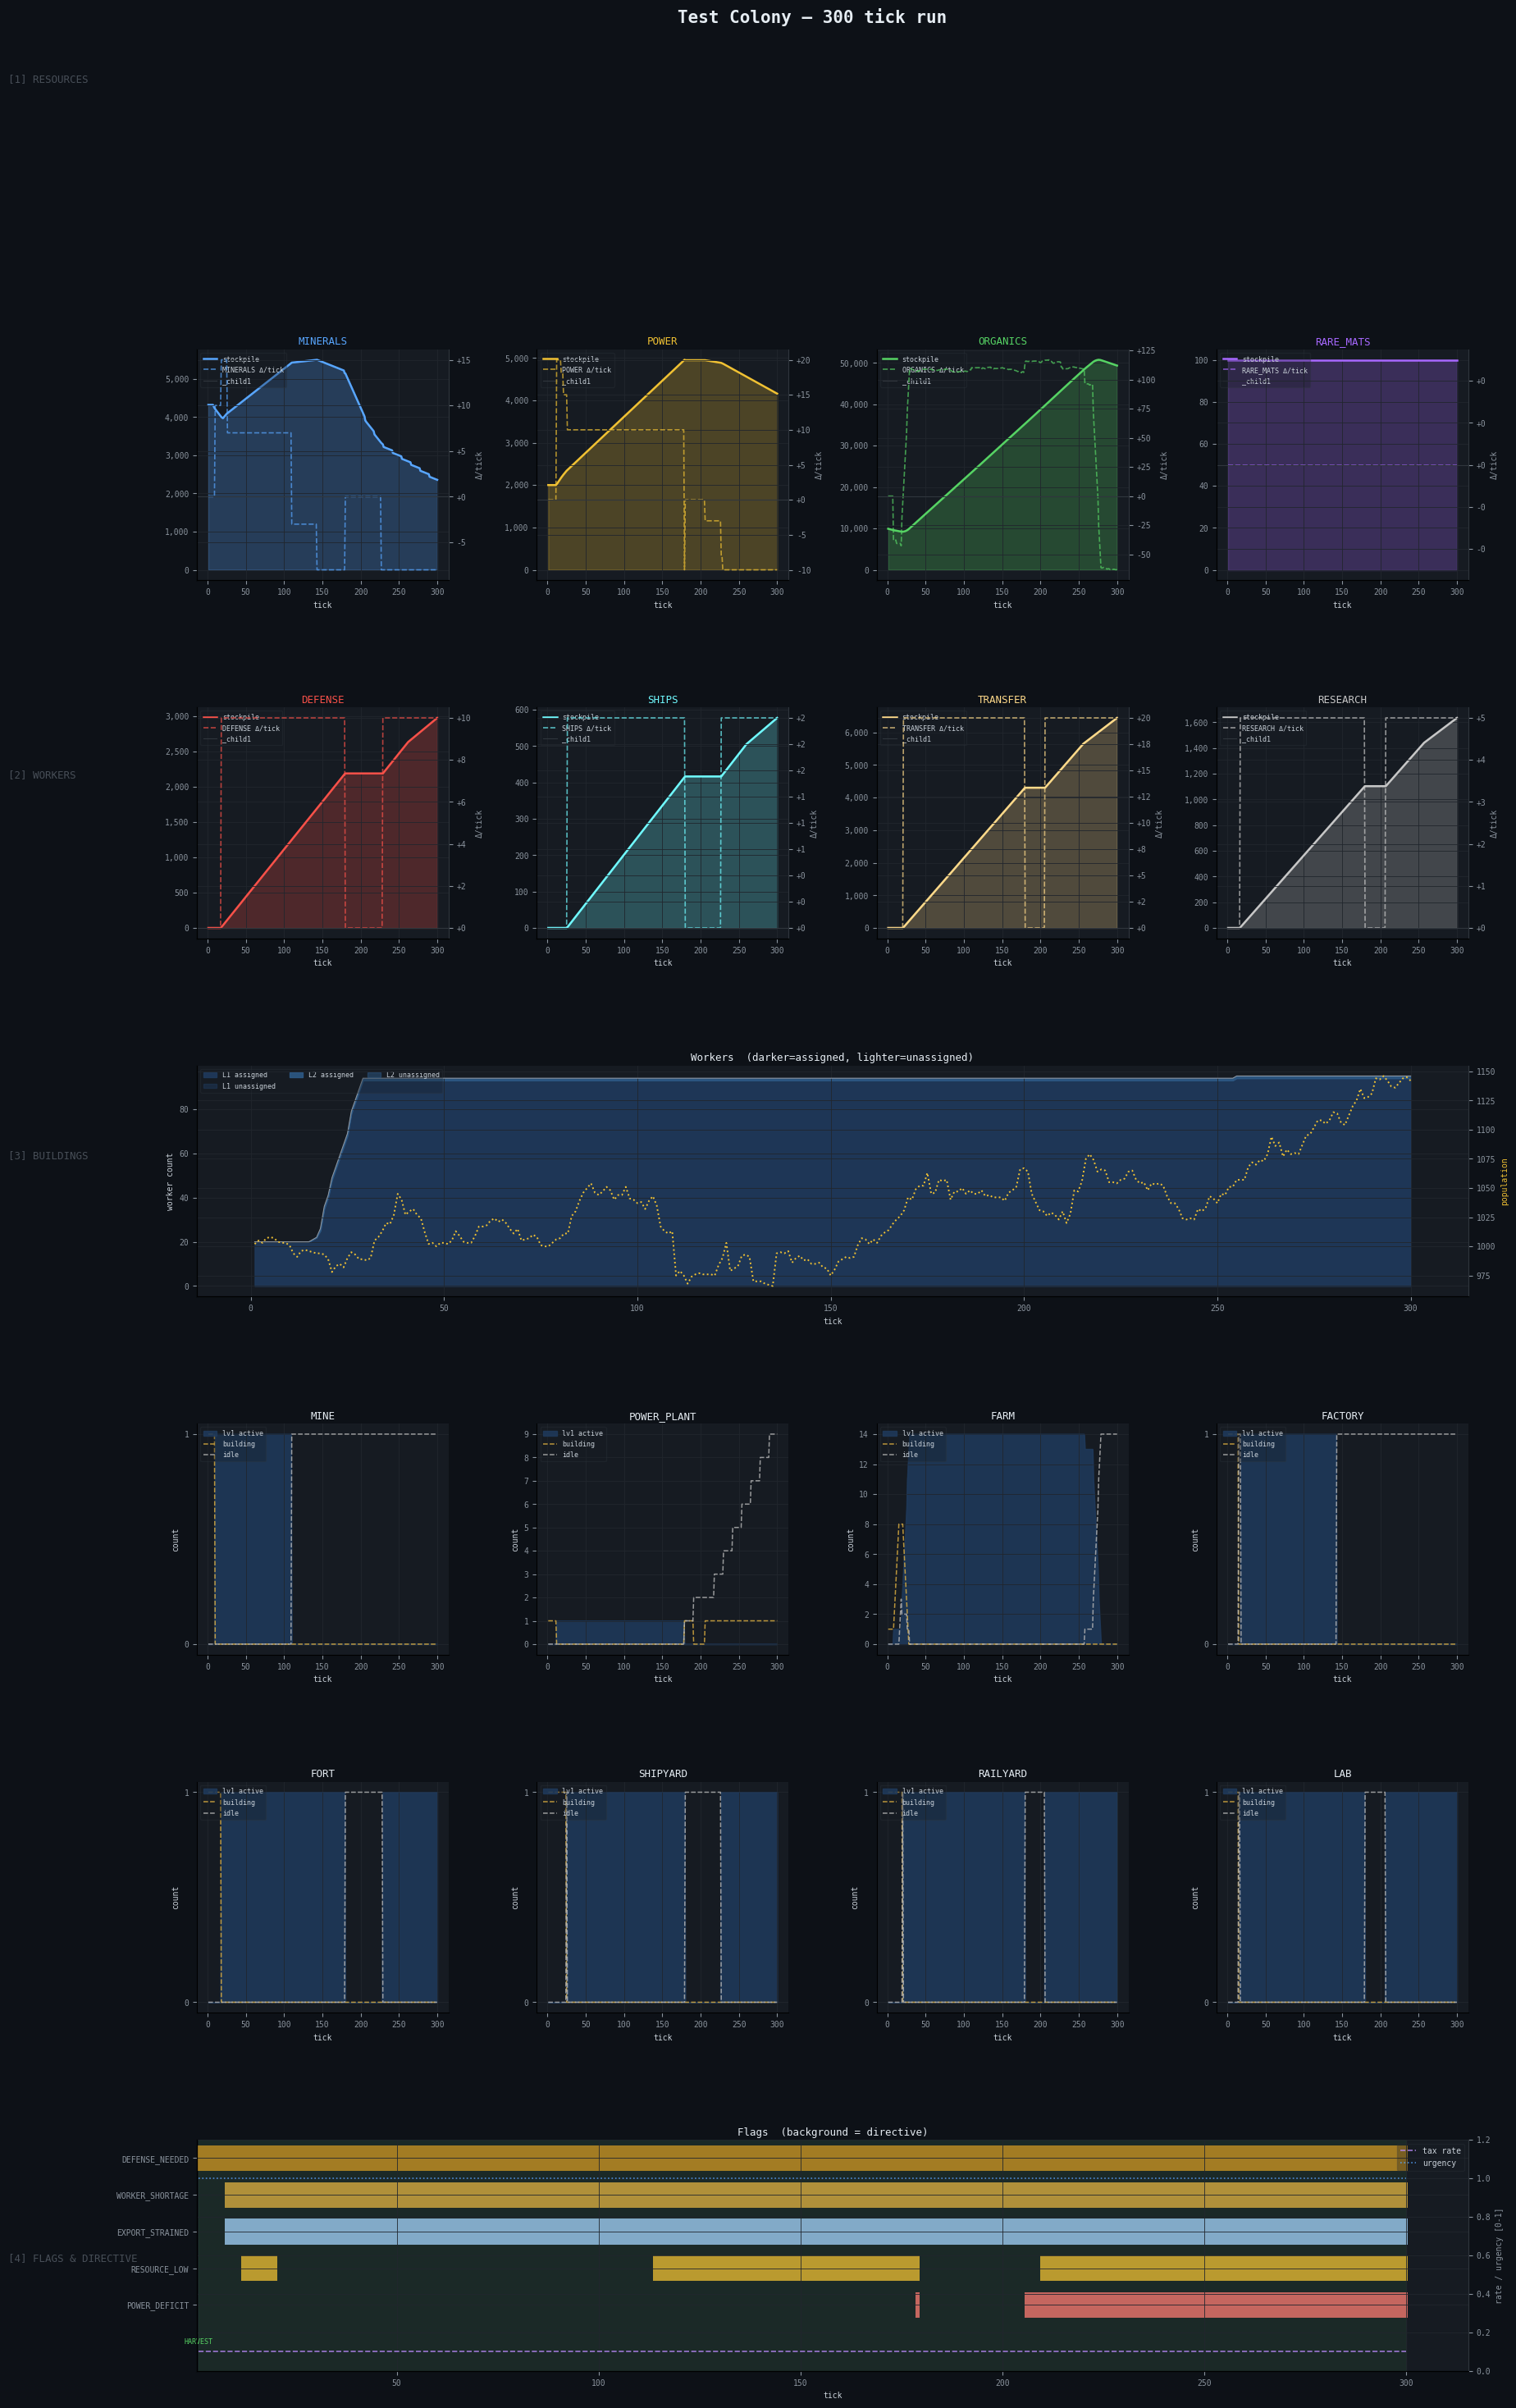

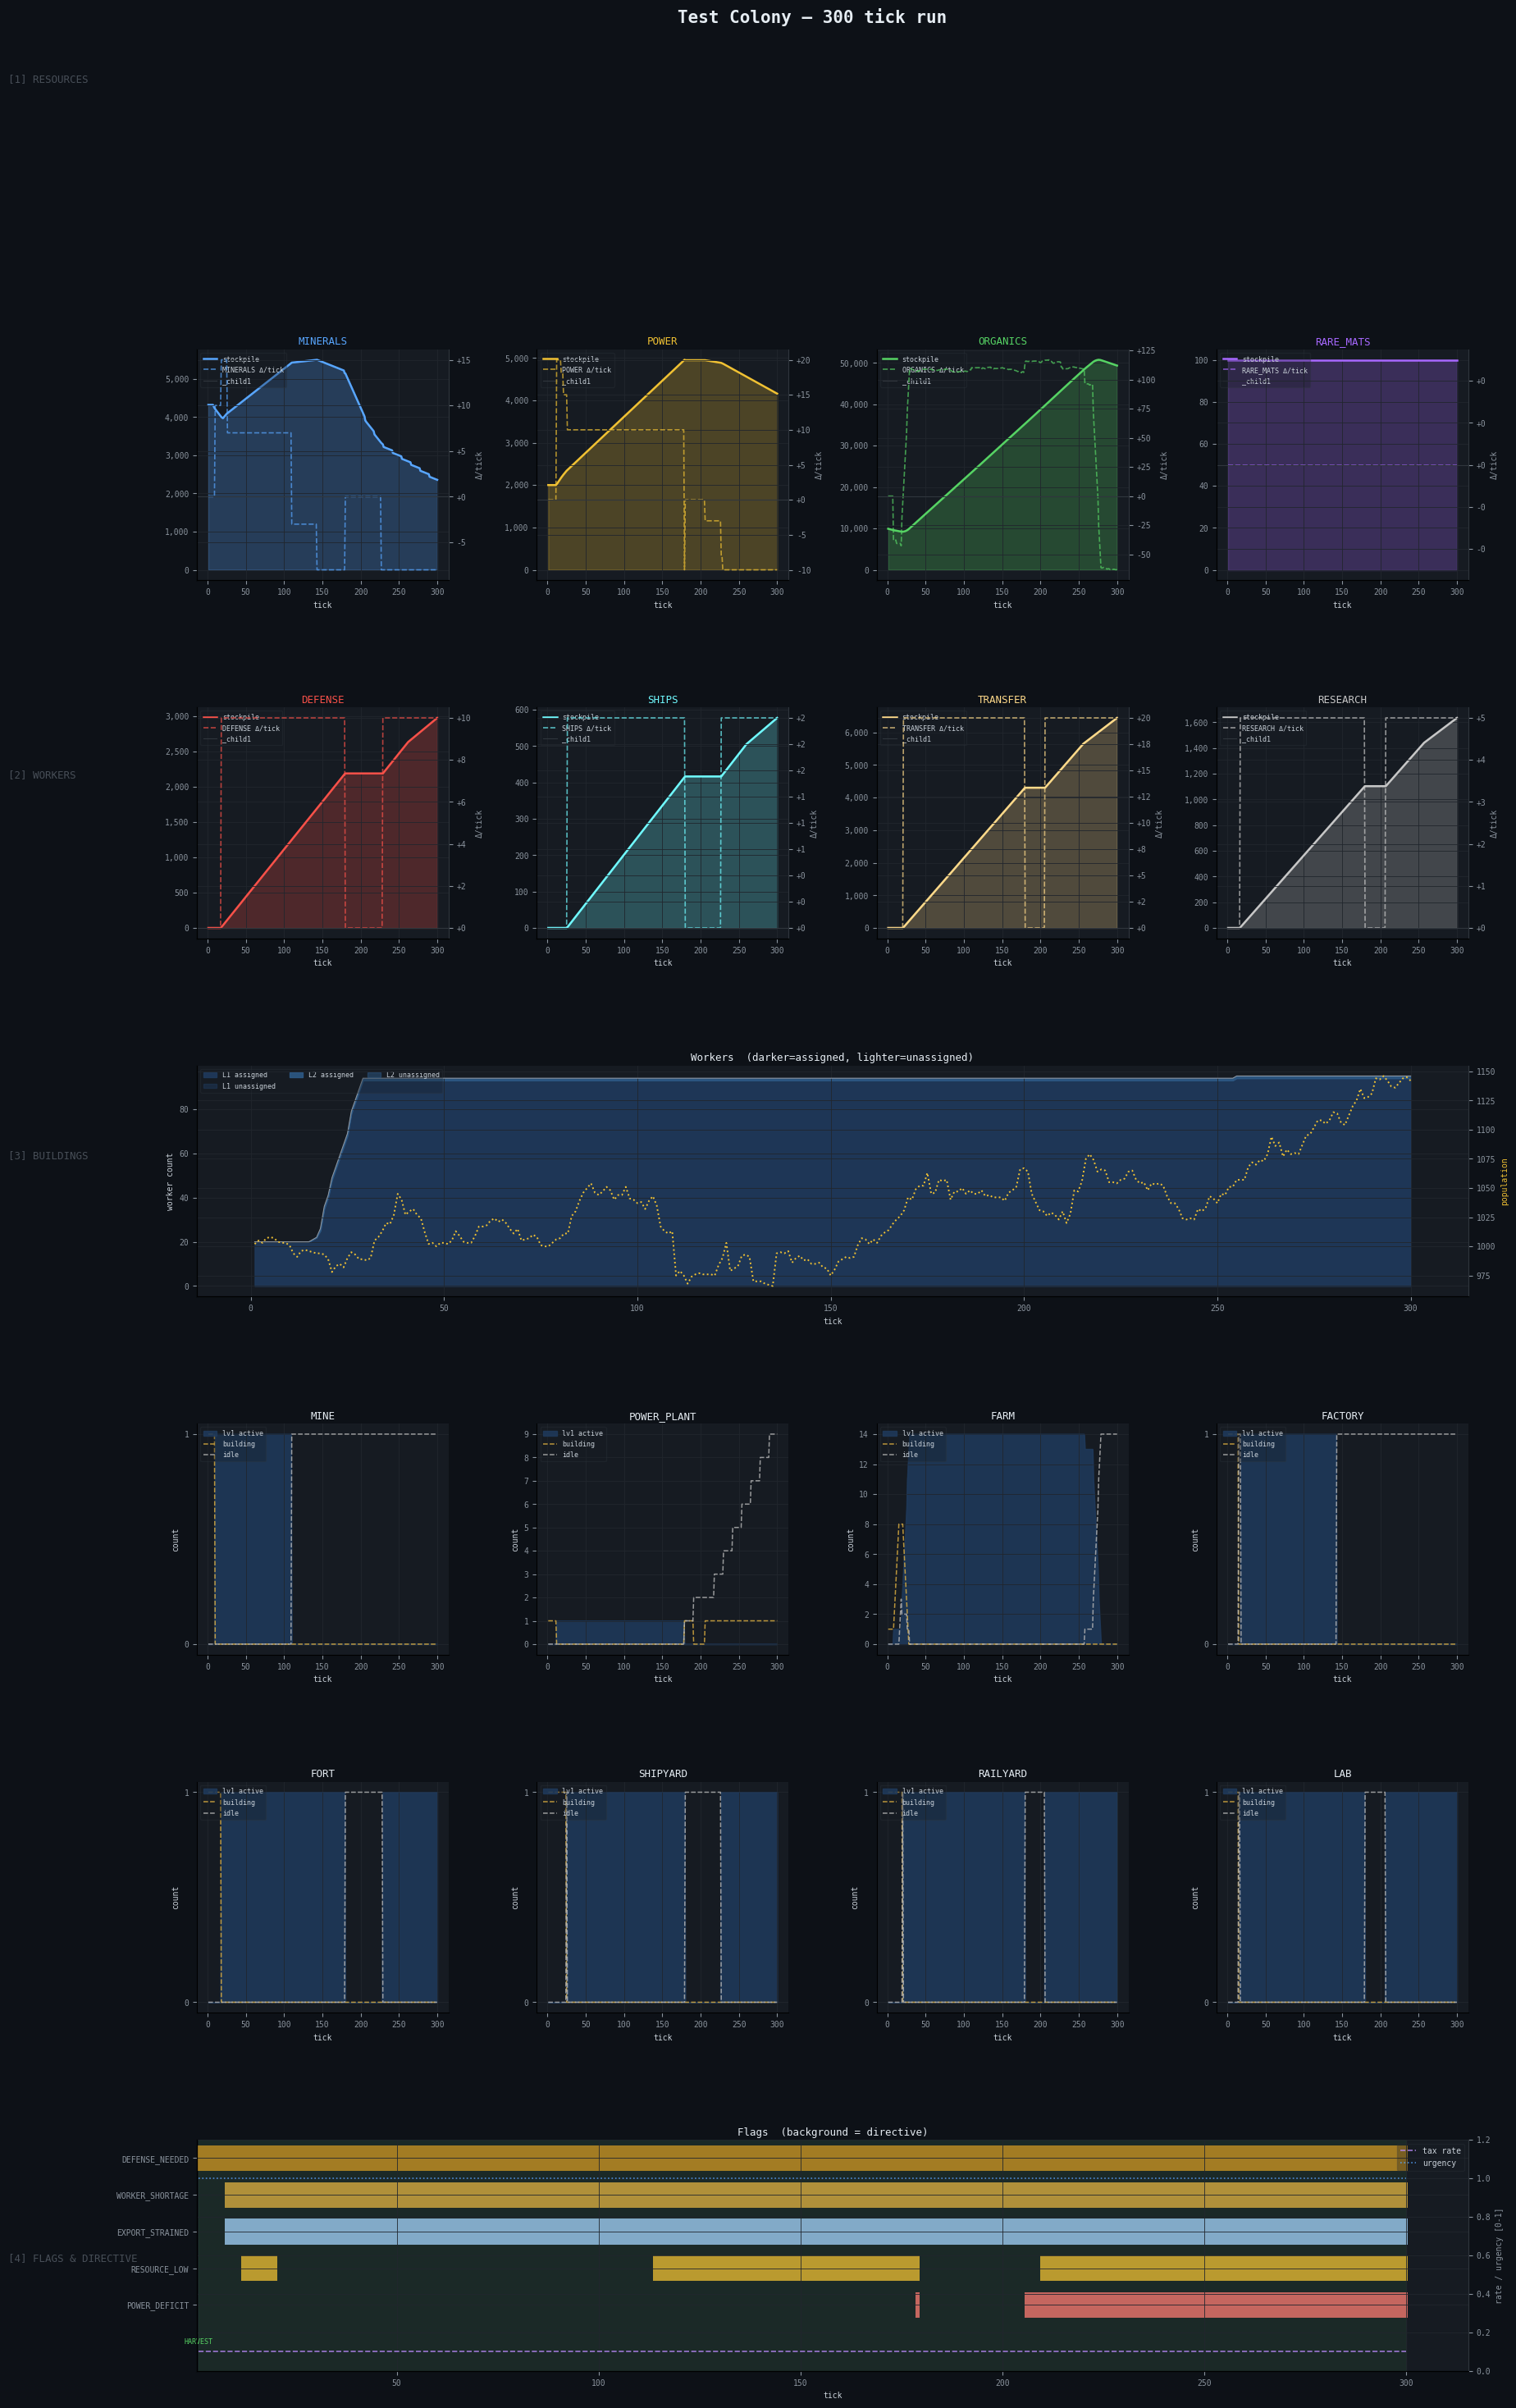

In [8]:
plot_history(history, title=f"{colony.name} — {NUM_TICKS} tick run", save_path=f"run_{NUM_TICKS}ticks.png")

In [9]:
# Print final colony state
print(colony.summary())

=== Colony: Test Colony (id=0)  tick=300 ===
  Directive : HARVEST  tax=10%  urgency=1.00
  Population:   1142.0  (free: 192.0, workers: 95)
  Organics upkeep/tick: 57.10
  Critical: [POWER_DEFICIT]  Strategic: [DEFENSE_NEEDED, WORKER_SHORTAGE, RESOURCE_LOW, EXPORT_STRAINED]
  Local stockpile:
    MINERALS     local=  2356.75  faction=     0.00
    WEALTH       local=     0.00  faction=     0.00
    ORGANICS     local= 49334.15  faction=     0.00
    RARE_MATS    local=   100.00  faction=     0.00
    POWER        local=  4157.00  faction=     0.00
    SOLDIERS     local=     0.00  faction=     0.00
    DEFENSE      local=  2979.00  faction=     0.00
    SHIPS        local=   577.80  faction=     0.00
    TRANSFER     local=  6444.00  faction=     0.00
    RESEARCH     local=  1633.50  faction=     0.00
  Buildings (30 total):
  [  0] MINE         lv1  DESTROYED    [░░░░░░░░░░░░░░░░░░░░]   0.0%
  [  1] POWER_PLANT  lv1  DESTROYED    [░░░░░░░░░░░░░░░░░░░░]   0.0%
  [  2] FARM         lv